# Credit Risk EDA and Cleaning Notebook

This notebook documents the exploratory data analysis and cleaning decisions used to prepare the credit risk dataset for downstream analytics and future predictive modeling.

The objective is not only to inspect the data, but also to justify why specific variables, records, or values may need to be corrected, filtered, or excluded.

This work is aligned with the business interpretation and visual review previously developed in the Google Sheets management system.

## Notebook goals

- Understand the dataset structure and variable roles
- Identify missing values and potential quality issues
- Detect outliers that could distort the analysis or the future neural network
- Document cleaning decisions in a reproducible way
- Export a cleaned version of the dataset for the next modeling stage

## Data source and supporting material

**Dataset source**  
This project uses a public credit risk dataset obtained from Kaggle and repurposed as an applied portfolio case for business-oriented analysis and experimentation.

**Why this dataset was used**  
It was selected because it contains enough demographic, financial, and credit-related variables to simulate a realistic credit evaluation workflow, support exploratory analysis, and prepare a future predictive modeling stage.

**Google Sheets support layer**  
Part of the decision-making process was also supported through a visual management sheet used to review patterns, risk segments, missing values, and unusual observations:

- [Credit risk management sheet](https://docs.google.com/spreadsheets/d/1c2M-y9EaVsJferSnKHW8X4KZPHc7syRw1yLrfvo3NxQ/edit?gid=311571590#gid=311571590)

The cleaning choices documented in this notebook are intended to reflect both the analytical review in Python and the visual insights identified in Google Sheets.

In [33]:
# Core libraries used for data manipulation, visualization, and exploratory analysis.
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [34]:
# Project paths are centralized here to make the notebook easier to reuse locally or in Kaggle.
# Load the original dataset used as the analytical starting point for the project.
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "credit_risk_dataset.csv"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "credit_risk_clean.csv"

df = pd.read_csv(DATA_RAW)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Dataset overview

In [35]:
# Review dataset size, available fields, and data types before applying any transformation.
print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print(f"- {col}")

df.info()

Shape: (32581, 12)

Columns:
- person_age
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_grade
- loan_amnt
- loan_int_rate
- loan_status
- loan_percent_income
- cb_person_default_on_file
- cb_person_cred_hist_length
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income 

In [36]:
# Summary statistics help identify early signs of skewness, unusual ranges, and candidate variables for deeper review.
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,"32,581.00",NaN,NaN,NaN,27.73,6.35,20.00,23.00,26.00,30.00,144.00
person_income,"32,581.00",NaN,NaN,NaN,"66,074.85","61,983.12","4,000.00","38,500.00","55,000.00","79,200.00","6,000,000.00"
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,"31,686.00",NaN,NaN,NaN,4.79,4.14,0.00,2.00,4.00,7.00,123.00
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,"32,581.00",NaN,NaN,NaN,"9,589.37","6,322.09",500.00,"5,000.00","8,000.00","12,200.00","35,000.00"
loan_int_rate,"29,465.00",NaN,NaN,NaN,11.01,3.24,5.42,7.90,10.99,13.47,23.22
loan_status,"32,581.00",NaN,NaN,NaN,0.22,0.41,0.00,0.00,0.00,0.00,1.00
loan_percent_income,"32,581.00",NaN,NaN,NaN,0.17,0.11,0.00,0.09,0.15,0.23,0.83


## Missing values

At this stage, missing values are reviewed before any transformation. This is important because incomplete variables may affect both descriptive analysis and the training of a future neural network.

In [37]:
# Build a compact missing-value table to understand which variables may require imputation or filtering.
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_values": missing, "missing_pct": missing_pct})
missing_table[missing_table["missing_values"] > 0]

,missing_values,missing_pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75


### Initial interpretation

- `loan_int_rate` contains a significant number of missing values and may require imputation or selective exclusion.
- `person_emp_length` also contains missing values and should be reviewed against business logic before filling or removing records.
- These decisions should remain explicit because they affect future model behavior.

## Numeric outlier review

The visual review performed in Google Sheets suggested that several variables contain extreme values that may not be realistic in a business context. The following section helps validate those observations analytically.

In [38]:
# Quantile inspection helps validate whether the extreme values spotted in Google Sheets are also visible numerically.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].quantile([0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]).transpose()

,0.00,0.01,0.05,0.50,0.95,0.99,1.00
person_age,20.00,21.00,22.00,26.00,40.00,50.00,144.00
person_income,"4,000.00","14,400.00","22,880.00","55,000.00","138,000.00","225,200.00","6,000,000.00"
person_emp_length,0.00,0.00,0.00,4.00,13.00,18.00,123.00
loan_amnt,500.00,"1,000.00","2,000.00","8,000.00","24,000.00","29,800.00","35,000.00"
loan_int_rate,5.42,5.42,6.03,10.99,16.32,18.62,23.22
loan_status,0.00,0.00,0.00,0.00,1.00,1.00,1.00
loan_percent_income,0.00,0.02,0.04,0.15,0.38,0.50,0.83
cb_person_cred_hist_length,2.00,2.00,2.00,4.00,14.00,17.00,30.00


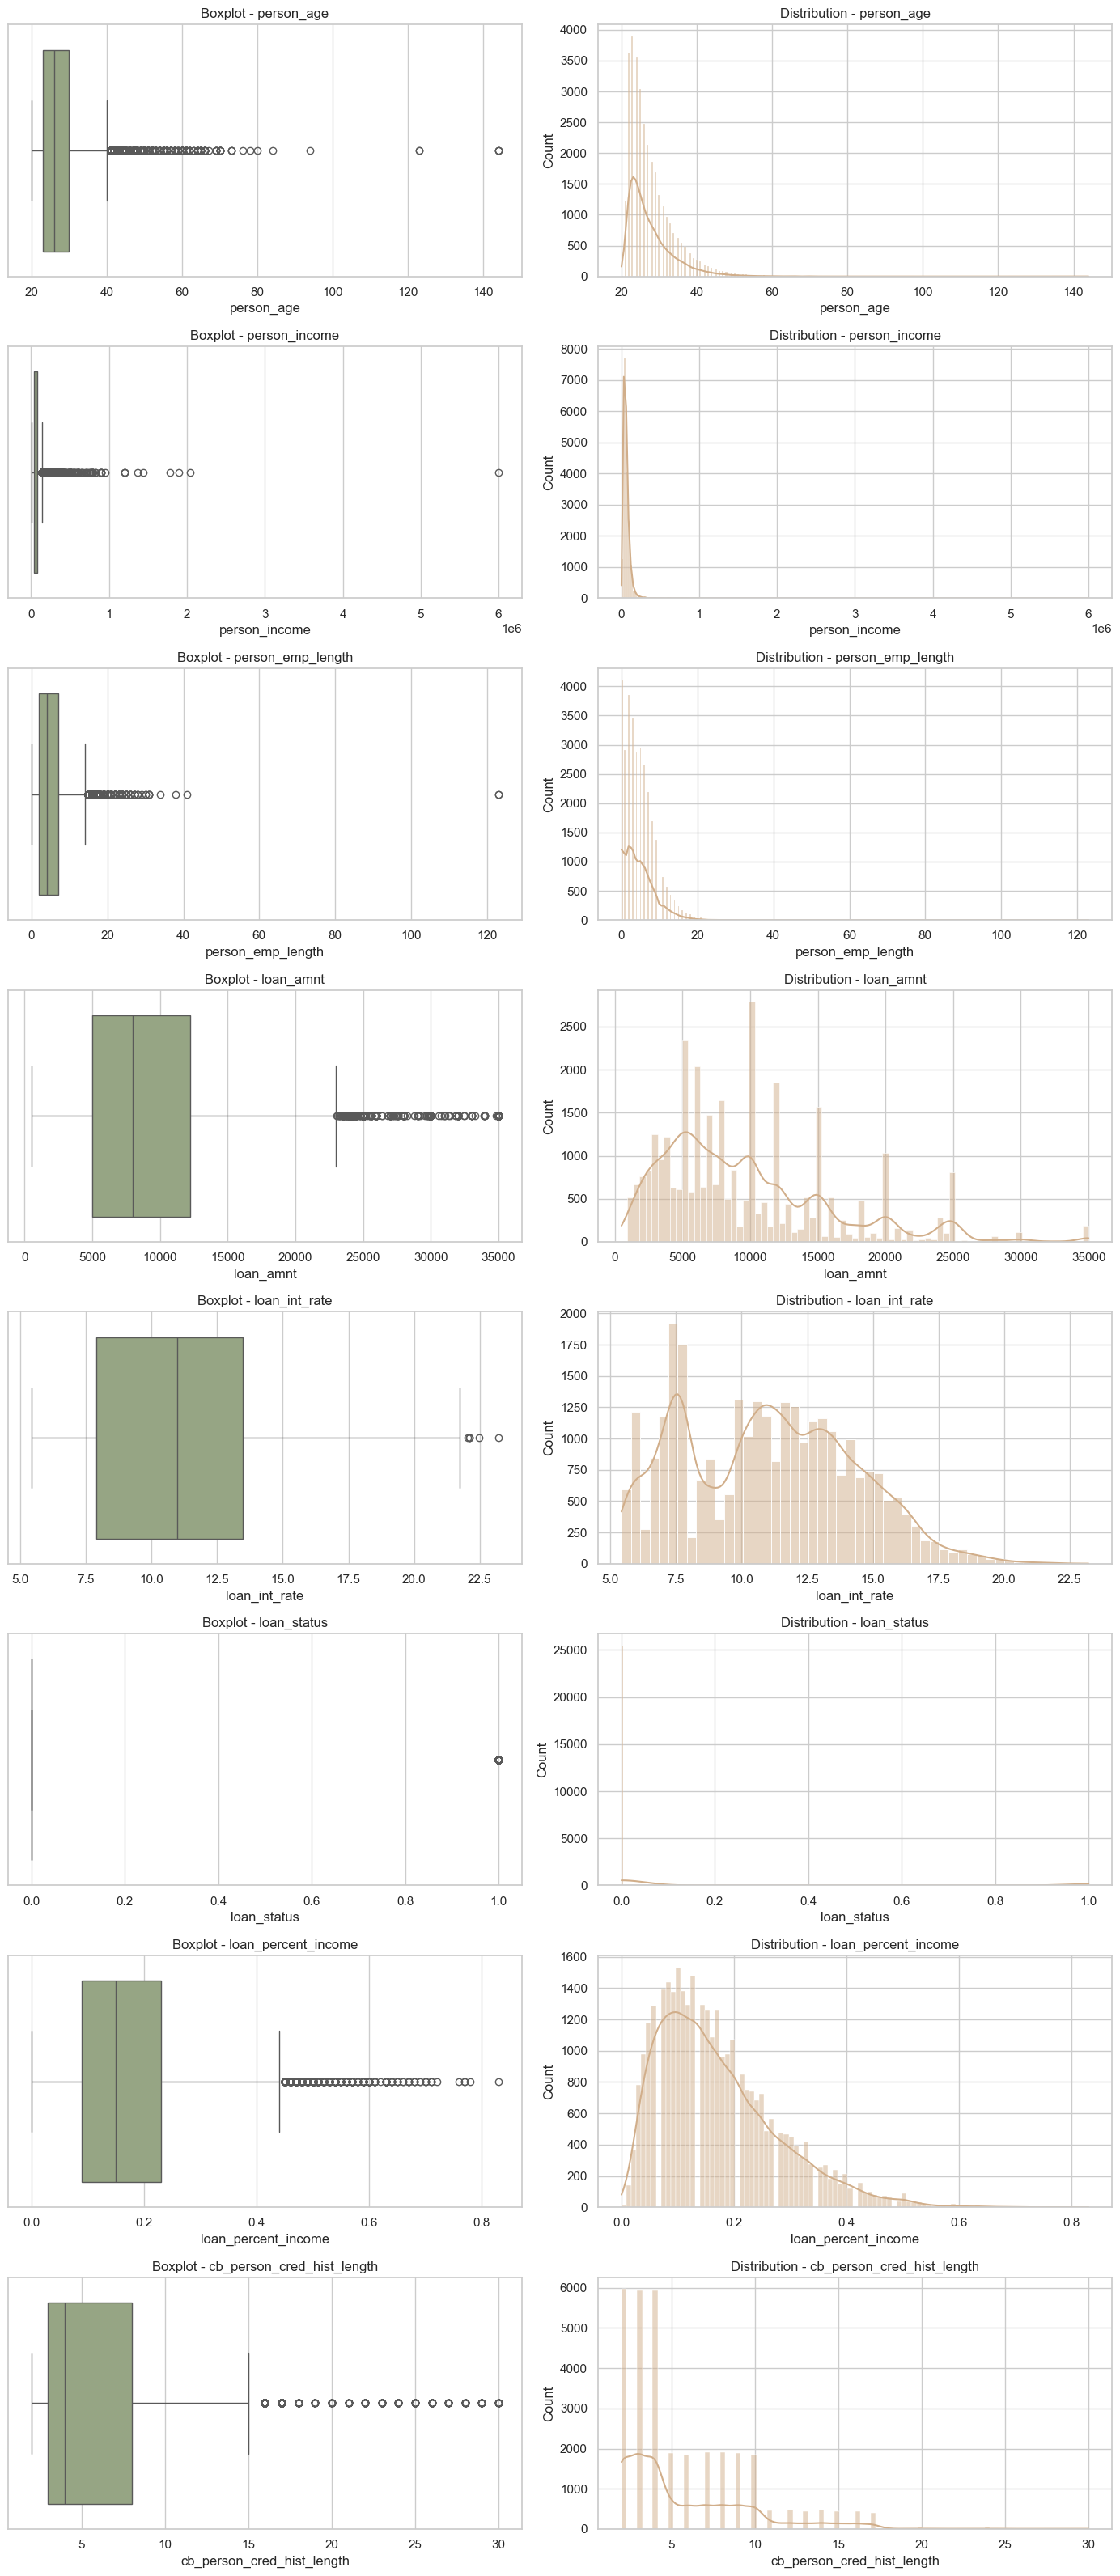

In [23]:
# Visual inspection supports the identification of skewed distributions, long tails, and outliers.
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i, 0], color="#97ab7f")
    axes[i, 0].set_title(f"Boxplot - {col}")
    sns.histplot(df[col], kde=True, ax=axes[i, 1], color="#d1ae8a")
    axes[i, 1].set_title(f"Distribution - {col}")

plt.tight_layout()

### Variables that deserve special attention

Based on the initial data inspection, the following variables are likely candidates for cleaning or filtering:

- `person_age`
- `person_income`
- `person_emp_length`
- `loan_percent_income`
- `loan_int_rate`

These variables may contain unrealistic values, missing information, or patterns that could reduce model reliability.

## Outlier flags with IQR rule

In [24]:
# Build a summary table showing how frequently each numeric field contains outliers.
def iqr_bounds(series):
    """Return lower and upper bounds using the interquartile range rule.

    This helper is used to flag observations that fall far outside
    the expected distribution of a numeric variable.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

outlier_summary = []

for col in numeric_cols:
    lower, upper = iqr_bounds(df[col].dropna())
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(mask.mean() * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)
outlier_table

,column,lower_bound,upper_bound,outlier_count,outlier_pct
5,loan_status,0.00,0.00,7108,21.82
3,loan_amnt,"-5,800.00","23,000.00",1689,5.18
0,person_age,12.50,40.50,1494,4.59
1,person_income,"-22,550.00","140,250.00",1484,4.55
7,cb_person_cred_hist_length,-4.50,15.50,1142,3.51
2,person_emp_length,-5.50,14.50,853,2.62
6,loan_percent_income,-0.12,0.44,651,2.00
4,loan_int_rate,-0.46,21.83,6,0.02


## Preliminary cleaning strategy

This section is intended to connect the visual analysis from Google Sheets with the reproducible logic implemented in Python.

Suggested rationale:

- Remove or cap clearly unrealistic values that do not represent a credible applicant profile.
- Review whether nulls should be imputed, filtered, or preserved depending on their analytical relevance.
- Preserve business meaning whenever possible instead of applying aggressive transformations without explanation.
- Keep this cleaning stage transparent because it will define the quality of the future predictive model.

## Cleaning rules draft

The following rules are written as an initial analytical proposal and should be validated against business interpretation:

1. Remove unrealistic ages.
2. Remove unrealistic employment length values.
3. Review very high income values as potential outliers.
4. Decide how to handle missing interest rates.
5. Decide how to handle missing employment length values.
6. Preserve the target variable (`loan_status`) without alteration.

In [25]:
# Create a working copy so that cleaning decisions remain explicit and reversible.
df_clean = df.copy()

# Example business-oriented filters based on unrealistic profiles observed during EDA.
df_clean = df_clean[df_clean["person_age"].between(18, 80)]
df_clean = df_clean[df_clean["person_emp_length"].isna() | df_clean["person_emp_length"].between(0, 60)]

# Missing value treatment proposal. Median imputation is used here as a stable baseline.
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(df_clean["loan_int_rate"].median())
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(df_clean["person_emp_length"].median())

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
df_clean.head()

Original shape: (32581, 12)
Cleaned shape: (32572, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.00,VENTURE,A,2500,7.14,1,0.25,N,2


## Post-cleaning validation

In [26]:
# Recheck missing values after applying the preliminary cleaning rules.
df_clean.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [27]:
# Review descriptive statistics again to verify whether the cleaned dataset looks more consistent.
df_clean.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,"32,572.00",NaN,NaN,NaN,27.71,6.19,20.00,23.00,26.00,30.00,80.00
person_income,"32,572.00",NaN,NaN,NaN,"65,878.88","52,532.79","4,000.00","38,500.00","55,000.00","79,200.00","2,039,784.00"
person_home_ownership,32572,4,RENT,16441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,"32,572.00",NaN,NaN,NaN,4.76,3.98,0.00,2.00,4.00,7.00,41.00
loan_intent,32572,6,EDUCATION,6451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32572,7,A,10775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,"32,572.00",NaN,NaN,NaN,"9,588.10","6,320.42",500.00,"5,000.00","8,000.00","12,200.00","35,000.00"
loan_int_rate,"32,572.00",NaN,NaN,NaN,11.01,3.08,5.42,8.49,10.99,13.11,23.22
loan_status,"32,572.00",NaN,NaN,NaN,0.22,0.41,0.00,0.00,0.00,0.00,1.00
loan_percent_income,"32,572.00",NaN,NaN,NaN,0.17,0.11,0.00,0.09,0.15,0.23,0.83


## Cleaning summary log

This section records the most relevant transformations applied during the cleaning stage so the dataset preparation remains transparent and reproducible.

In [28]:
# Build a compact log describing how many records were filtered and how missing values were treated.
cleaning_log = pd.DataFrame([
    {"step": "Original rows", "value": len(df)},
    {"step": "Rows after age filter", "value": int(df[df['person_age'].between(18, 80)].shape[0])},
    {"step": "Rows after employment length filter", "value": int(df_clean.shape[0])},
    {"step": "Missing loan_int_rate before imputation", "value": int(df['loan_int_rate'].isna().sum())},
    {"step": "Missing person_emp_length before imputation", "value": int(df['person_emp_length'].isna().sum())},
    {"step": "Missing loan_int_rate after imputation", "value": int(df_clean['loan_int_rate'].isna().sum())},
    {"step": "Missing person_emp_length after imputation", "value": int(df_clean['person_emp_length'].isna().sum())},
    {"step": "Rows removed in total", "value": int(len(df) - len(df_clean))}
])
cleaning_log

,step,value
0,Original rows,32581
1,Rows after age filter,32574
2,Rows after employment length filter,32572
3,Missing loan_int_rate before imputation,3116
4,Missing person_emp_length before imputation,895
5,Missing loan_int_rate after imputation,0
6,Missing person_emp_length after imputation,0
7,Rows removed in total,9


## Sample of affected records

The following examples help illustrate the type of records that motivated the filtering decisions, especially unrealistic values detected during the exploratory review.

In [29]:
# Display examples of records flagged by the main cleaning rules.
age_outliers = df[~df['person_age'].between(18, 80)][['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_status']].head(10)
emp_outliers = df[(df['person_emp_length'].notna()) & (~df['person_emp_length'].between(0, 60))][['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_status']].head(10)

print('Examples of age-related outliers:')
display(age_outliers)
print('Examples of employment-length outliers:')
display(emp_outliers)

Examples of age-related outliers:


,person_age,person_income,person_emp_length,loan_amnt,loan_status
81,144,250000,4.00,4800,0
183,144,200000,4.00,6000,0
575,123,80004,2.00,20400,0
747,123,78000,7.00,20000,0
32297,144,6000000,12.00,5000,0
32416,94,24000,1.00,6500,0
32506,84,94800,2.00,10000,0


Examples of employment-length outliers:


,person_age,person_income,person_emp_length,loan_amnt,loan_status
0,22,59000,123.00,35000,1
210,21,192000,123.00,20000,0


## Post-cleaning visual validation

These charts help confirm whether the cleaned dataset looks more consistent and suitable for later modeling stages.

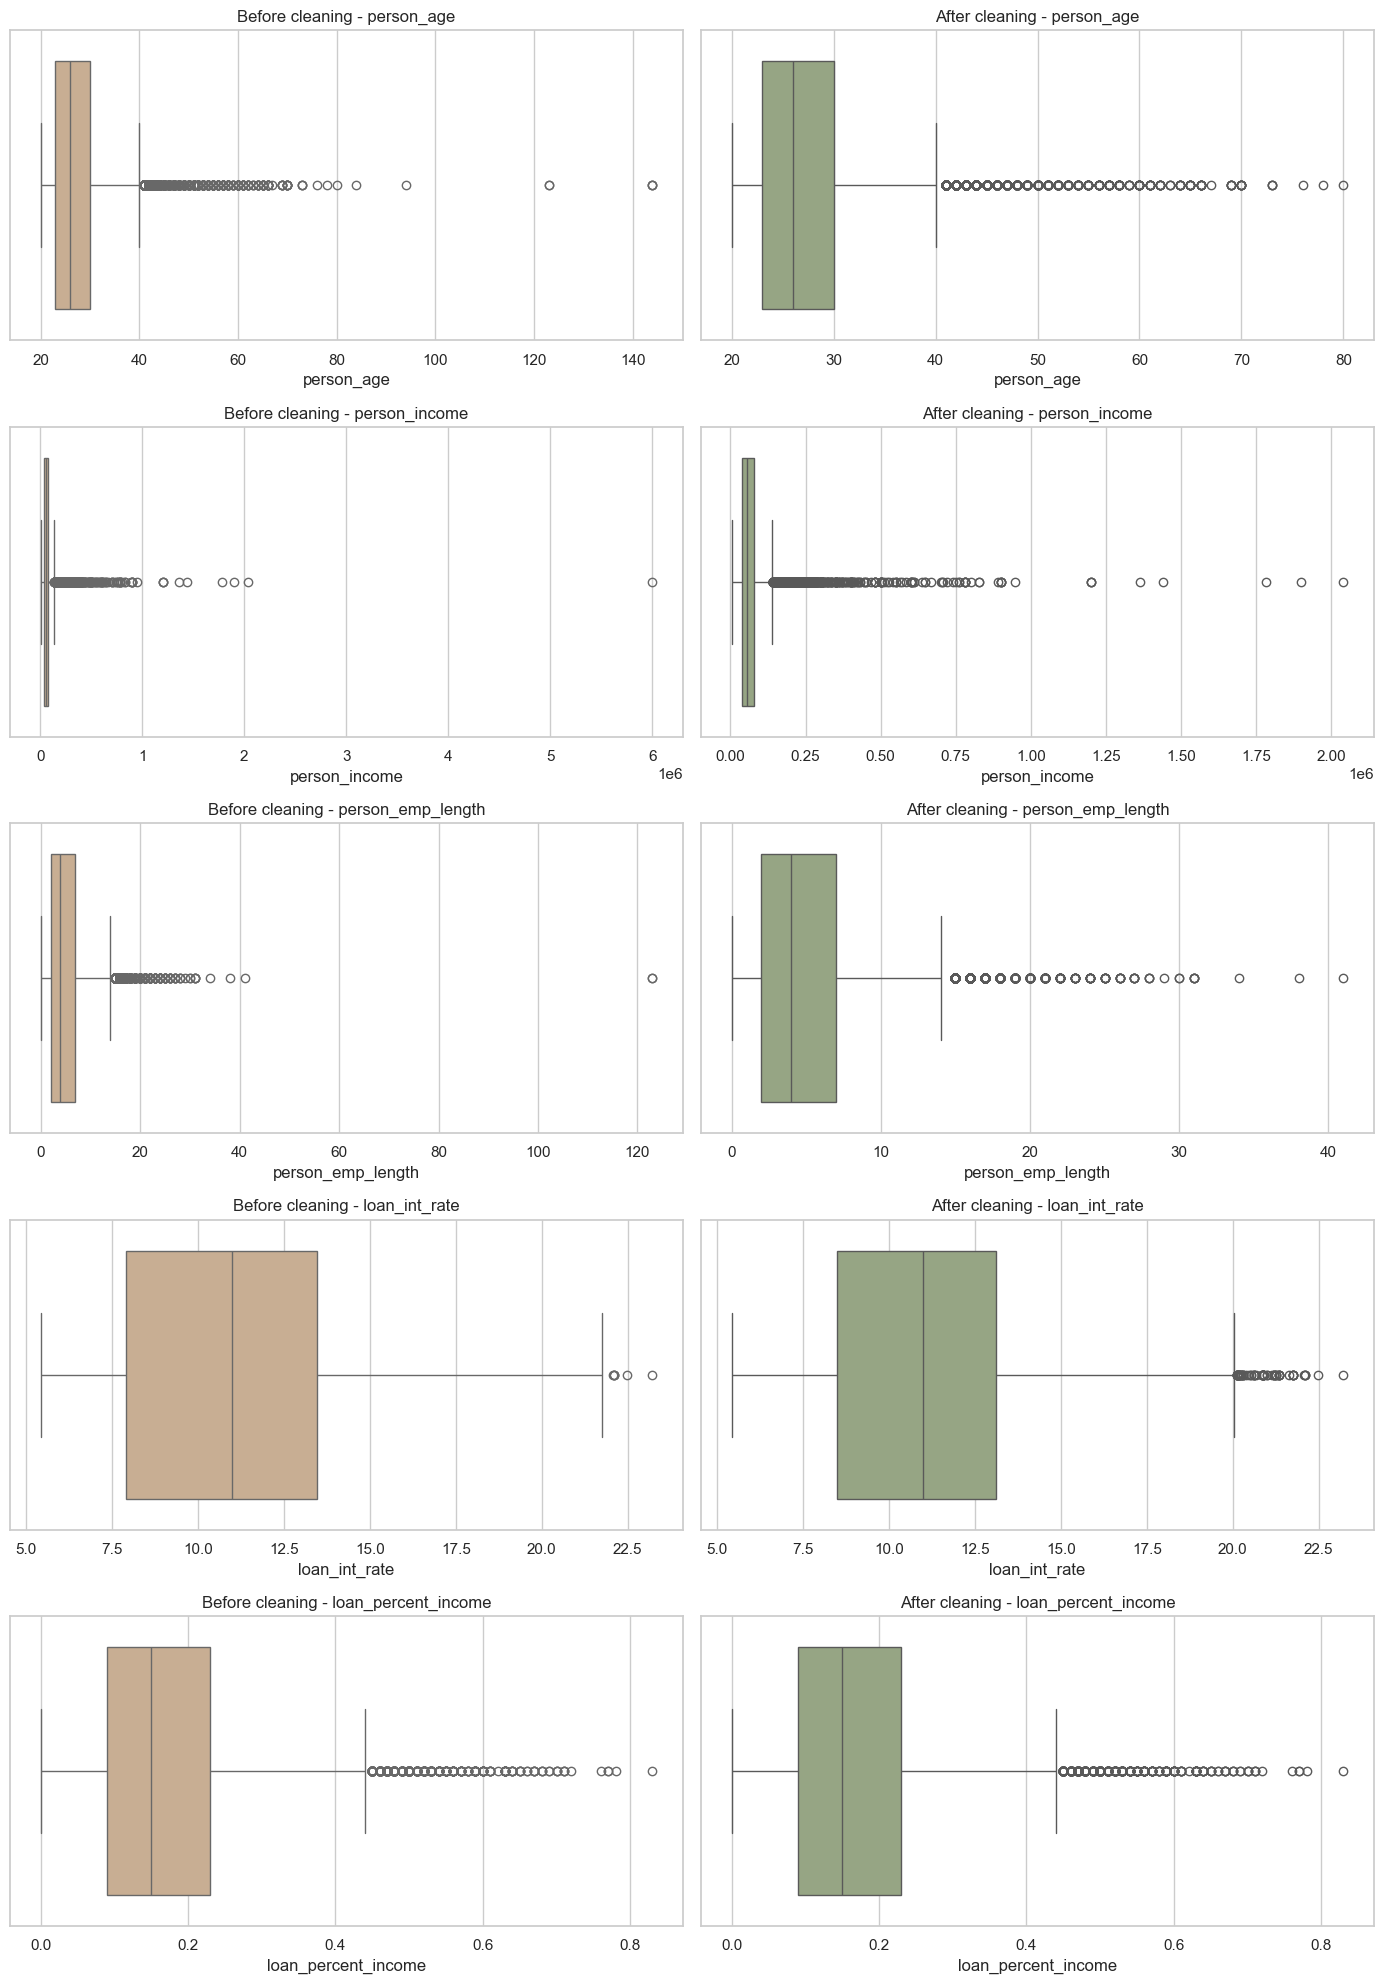

In [30]:
# Compare key numeric distributions before and after cleaning.
comparison_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_int_rate', 'loan_percent_income']
fig, axes = plt.subplots(len(comparison_cols), 2, figsize=(14, 4 * len(comparison_cols)))

for i, col in enumerate(comparison_cols):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='#d1ae8a')
    axes[i, 0].set_title(f'Before cleaning - {col}')

    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color='#97ab7f')
    axes[i, 1].set_title(f'After cleaning - {col}')

plt.tight_layout()

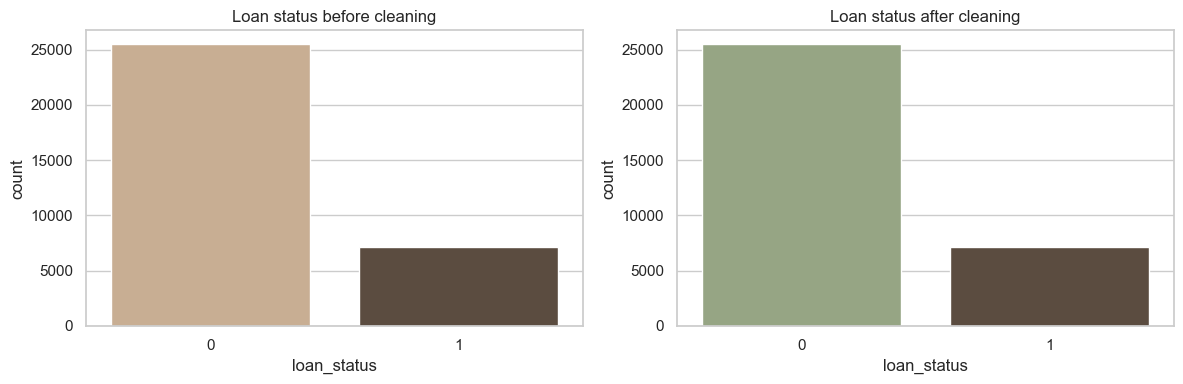

In [31]:
# Inspect post-cleaning category balance for the target variable.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='loan_status', hue='loan_status', data=df, ax=axes[0], palette=['#d1ae8a', '#5f4c3b'], legend=False)
axes[0].set_title('Loan status before cleaning')

sns.countplot(x='loan_status', hue='loan_status', data=df_clean, ax=axes[1], palette=['#97ab7f', '#5f4c3b'], legend=False)
axes[1].set_title('Loan status after cleaning')

plt.tight_layout()

## Export cleaned dataset

This exported file can be used later for:

- Tableau or dashboard refinement
- Kaggle notebook publication
- Feature engineering
- Neural network experimentation

In [32]:
# Export the cleaned dataset so it can feed dashboards, notebooks, or predictive experiments.
DATA_PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(DATA_PROCESSED, index=False)
print(f"Cleaned dataset exported to: {DATA_PROCESSED}")

Cleaned dataset exported to: C:\Users\fredy\Desktop\Proyectos\Analisis de Datos\Riesgo Crediticio\data\processed\credit_risk_clean.csv


## Next step

Once the cleaning decisions are confirmed, this notebook can evolve into a stronger analytical pipeline by adding:

- categorical encoding strategy
- train/validation/test split
- baseline model comparison
- neural network experimentation
- model explainability review